# Training, analysis and validation 

In this notebook you can find: 
1. Training procedure
2. First analysis of the network. 
3. Validation

In the first part we load the data, we prepare the dataset and we start the training procedure.
In the second part we load the model and we analyze some preliminary data. These data will be useful to define if the training succeded and the network actually learned what we would expect it to learn.
In the third part we do a quick validation of the learned committor.

In [31]:
%load_ext autoreload
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader
import numpy as np
import torch
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm

import lipid_gnn.functions_emil.properties_nn as properties_nn
from lipid_gnn.functions_emil.functions import mkdir, pkl_load, pkl_save

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Training data

We construct a dataset from the raw outputs of the previously computed membrane properties, making it easier to use for training the property-prediction neural network.

In [32]:
%autoreload
raw_dataset = properties_nn.create_dataset('/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties',
                                    save='/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties_nn/properties_nn_dataset.npz')

membrane_compositions:    (70,) 
membrane_property_values: (70, 8) 
membrane_properties:      ('lipid_packing', 'thickness', 'thickness_std', 'compressibility', 'bending_modulus', 'persistence', 'diffusivity', 'variation')


# Training property nn

We train the model using a simple feed-forward neural network. For testing, we select 9 of the 70 membrane compositions to ensure that all lipid types present in the raw data are represented. After training, we evaluate the model on the entire dataset to assess its overall performance.

## Setup

In [33]:
# Training_parameters
Training_parameters = {'Batch_size'            : 63,
                       'Learning_rate'         : 1e-5,
                       'Epochs'                : 100000}

# Neural network parameters
NN_parameters       = {'Hidden_layers'         : [512, 512, 512],
                       'Activation_function'   : [torch.nn.PReLU(512),
                                                  torch.nn.PReLU(512),
                                                  torch.nn.PReLU(512)],
                       'Batch_norm'            : True,
                       'Dropout'               : 0.05}

# sweep name
Parameters_dict     = dict(**Training_parameters, **NN_parameters)

In [34]:
%autoreload
# Division of the trainins set in training and testing based on the first 5 pathensembles
test_set = ['POPC10_DIPC90','POPC10_DOPC90','POPC10_DPPC90',
            'POPC65_CHOL35','POPC65_DOPE35','POPC65_DPPE35',
            'POPC65_POPE35','POPC92_DOPS8','POPC92_POPS8']
#test_set = ["POPC30_DOPC70", "POPC30_DPPC70", "POPC40_DIPC60", 
#            "POPC60_DPPC40", "POPC65_DPPE35", "POPC70_CHOL30", 
#            "POPC70_POPE30", "POPC80_DPPC20", "POPC90_DOPS10",
#            "POPC90_DPPE10", "POPC98_POPS2"]
train_set = [comp for comp in raw_dataset['membrane_compositions'] if comp not in test_set]
test_dataset = properties_nn.ZMatrix(raw_dataset, iterator=test_set)
train_dataset = properties_nn.ZMatrix(raw_dataset, iterator=train_set)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Descriptors size: {test_dataset.descriptors.shape[-1]}")

Training set size: 61
Test set size: 9
Descriptors size: 10


## Training

, Epoch=1e+5, Train loss=81.3, best validation loss=[np.float64(13.47), np.float64(86.96)], max_error=13.5, max_error_prop=86.8   


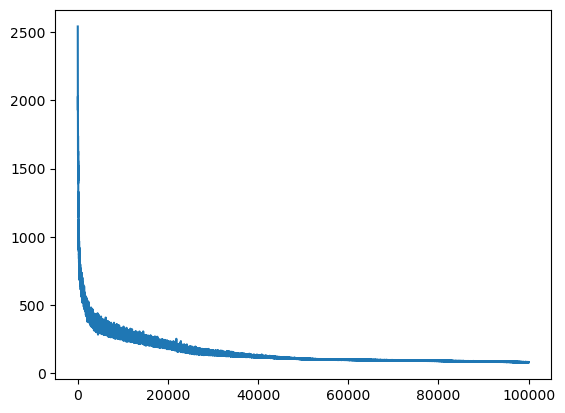

In [35]:
%autoreload

# Run training and save the network

network = properties_nn.Network(n_features=train_dataset.descriptors.shape[-1],
                         hidden_layers=Parameters_dict['Hidden_layers'],
                         activation=Parameters_dict['Activation_function'],
                         batch_norm=Parameters_dict['Batch_norm'],
                         dropout=Parameters_dict['Dropout'],
                         output_size=7)

network, optimizer, device, dtype = properties_nn.prepare_network(network,
                                                           lr=1e-5, #Parameters_dict['Learning_rate'], 
                                                           optimizer=None,
                                                           cuda=False,
                                                           save_path = '.')

train_losses, test_losses = properties_nn.train(network,
                                         100000, #Parameters_dict['Epochs'],
                                         Parameters_dict['Batch_size'], 
                                         optimizer,
                                         train_dataset,
                                         test_dataset,
                                         device,
                                         dtype,
                                         stop=200,
                                         verbose=True,
                                         min_train_loss= 0.00000,
                                         save_to='/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties_nn/best_properties_nn_model.h5')

plt.plot(train_losses)
plt.plot(test_losses)
#plt.axvline(np.argmin(test_losses), linestyle=':', color='black')

## Validation

In [36]:
best_model = pkl_load('/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties_nn/best_properties_nn_model.h5')
network = properties_nn.Network(**best_model[0])
network.load_state_dict(best_model[1])
network.to(device='cpu')

Network(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=512)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=512)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): PReLU(num_parameters=512)
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=7, bias=True)
  )
)

In [37]:
validation_dict = {}
results = []
for membrane_composition in raw_dataset['membrane_compositions']:
    
    # setup
    text = ''
    
    # estimate properties and load reference
    estimate = properties_nn.evaluate(network, np.array([properties_nn.transfer_membrane_comp(membrane_composition)]))
    properties, values = zip(*pkl_load(f'/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties/{membrane_composition}.h5')[0].items())
    reference = np.asanyarray(values)[[0,1,2,3,5,6,7]]      # exclude bending modulus
    properties = np.asanyarray(properties)[[0,1,2,3,5,6,7]] # exclude bending modulus
    
    # calculate error for each property and the maximum error in percent
    error = ((reference - estimate)/reference)*100
    error_max = np.max(np.abs(reference - estimate)/reference)*100
    
    # table construction
    text += '{:20s} | {:15s} | {:15s} | {:15s}\n'.format(membrane_composition, 'Reference', 'Estimate', 'Error [%]')
    text += '-'*len(text)+'\n'
    for i in np.arange(len(reference)):
        text += '{:20s} | {:15.4f} | {:15.4f} | {:15.4f}\n'.format(properties[i],
                                                                   reference[i],
                                                                   estimate[i],
                                                                   error[i])
    
    # append
    results.append(np.vstack(([reference], [estimate], [error])).T)
    validation_dict[membrane_composition] = text
validation_dict['results'] = np.asanyarray(results)

In [29]:
validation_dict["DIPC100"]

'DIPC100              | Reference       | Estimate        | Error [%]      \n---------------------------------------------------------------------------\nlipid_packing        |          2.6173 |          2.5956 |          0.8301\nthickness            |         34.7110 |         34.3574 |          1.0187\nthickness_std        |          2.2692 |          2.2544 |          0.6521\ncompressibility      |          5.3758 |          5.3756 |          0.0037\npersistence          |          0.0531 |          0.0548 |         -3.1694\ndiffusivity          |       1282.8861 |        169.1782 |         86.8127\nvariation            |          0.2825 |          0.2789 |          1.2545\n'

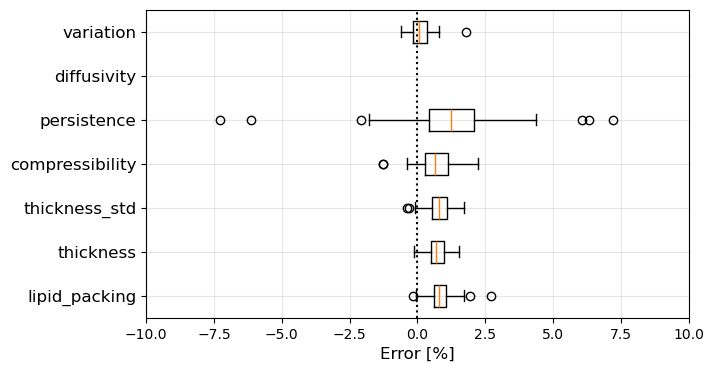

In [40]:
plt.figure(figsize=(7,4))
plt.boxplot(validation_dict['results'][:, :, -1], vert=False)
plt.axvline(0, color='black', linestyle=':')
plt.yticks(np.arange(1, 8, 1), labels=properties, rotation=0, fontsize=12)
plt.xlim(-10, 10)
plt.grid(alpha=0.3)
plt.xlabel('Error [%]', fontsize=12)
plt.savefig('/home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties_nn/property_nn_performance.pdf', bbox_inches='tight')
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:5: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_253795/4072338575.py:3: SyntaxWarning: invalid escape sequence '\A'
  'Thickness [$\AA$]',
/tmp/ipykernel_253795/4072338575.py:4: SyntaxWarning: invalid escape sequence '\A'
  'Thickness [$\AA$]',
/tmp/ipykernel_253795/4072338575.py:5: SyntaxWarning: invalid escape sequence '\A'
  'compressibility [$\AA^3 / kT]$',
/tmp/ipykernel_253795/4072338575.py:7: SyntaxWarning: invalid escape sequence '\A'
  'diffusivity [$\AA^2/lag$]',
/tmp/ipykernel_253795/4072338575.py:8: SyntaxWarning: i

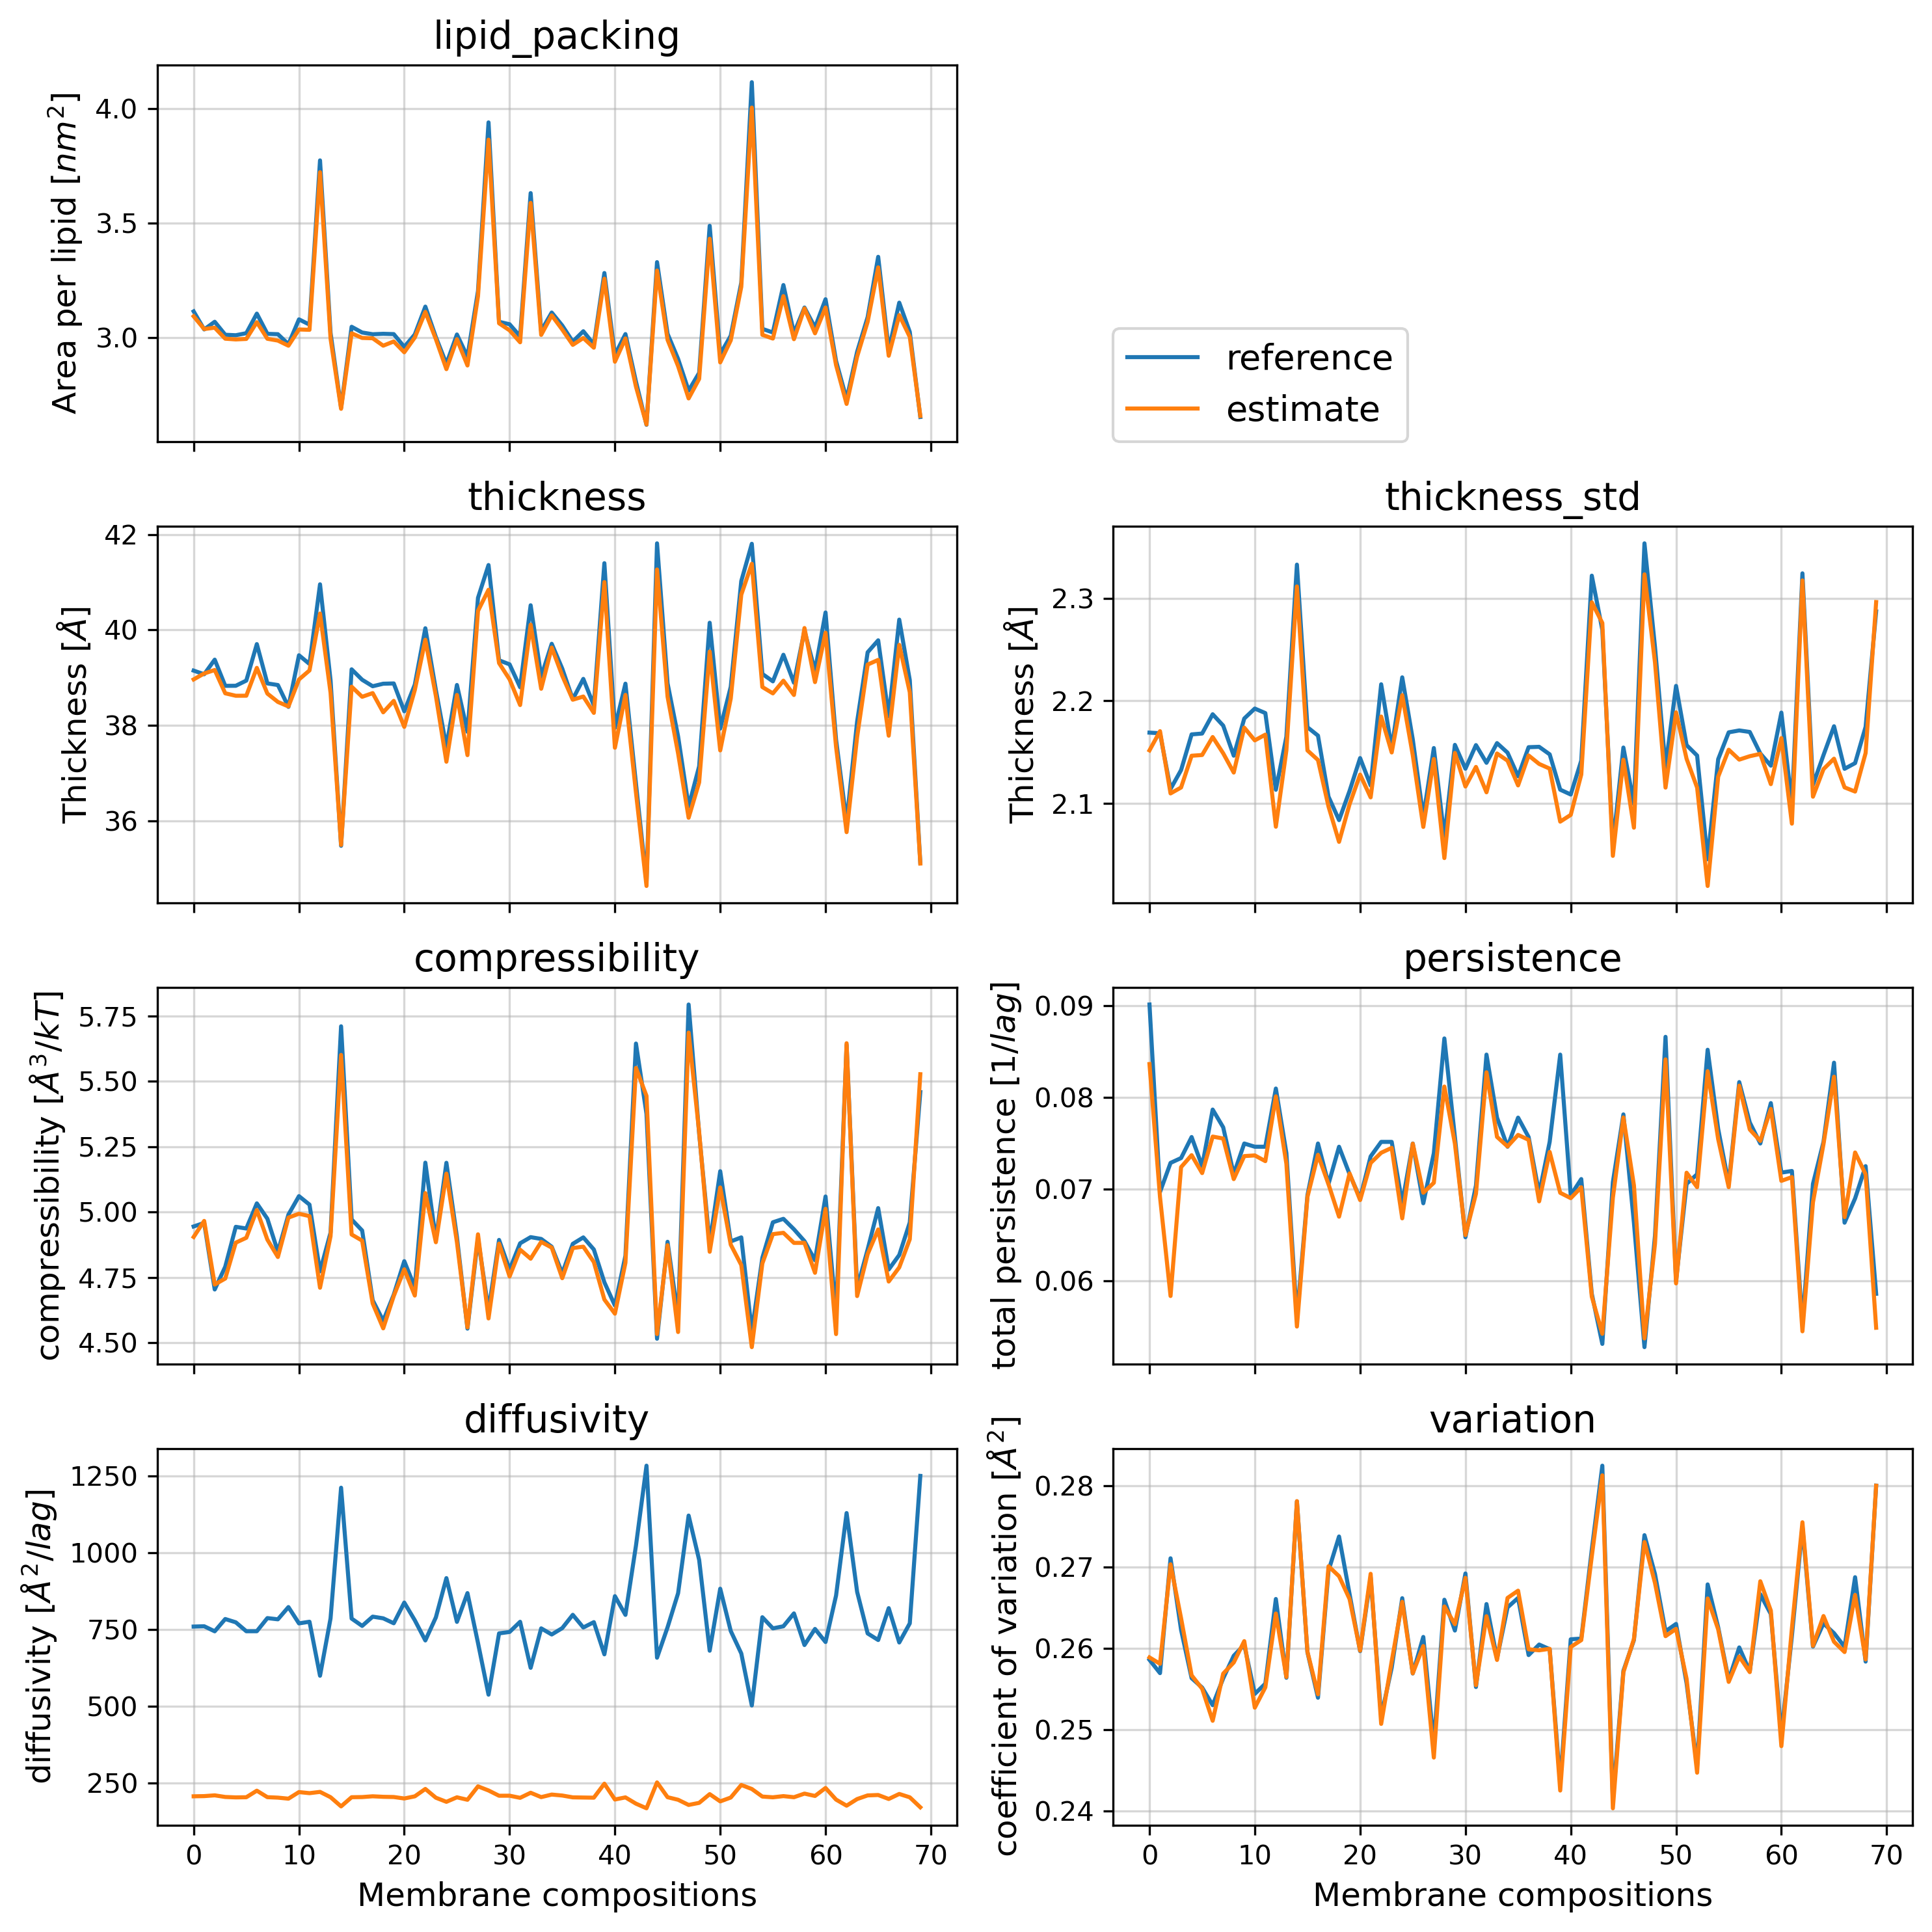

In [39]:
index = 0
units = ['Area per lipid [$nm ^2$]', 
         'Thickness [$\AA$]', 
         'Thickness [$\AA$]', 
         'compressibility [$\AA^3 / kT]$',
         'total persistence [$1/lag$]',
         'diffusivity [$\AA^2/lag$]',
         'coefficient of variation [$\AA^2$]']
fig, axes = plt.subplots(4, 2, figsize=(10, 10), dpi=300, sharex=True)
for i in range(8):
    
    ax = axes[int(i/2), i%2]  
    if i == 1:
        ax.plot(validation_dict['results'][:, index, :2], label=['reference', 'estimate'])
        ax.set_ylim(0,0.1)
        ax.legend(loc=(0, 0), fontsize=13)
        ax.axis('off')
        continue

    ax.plot(validation_dict['results'][:, index, :2], label=['reference', 'estimate'])
    ax.set_title(properties[index], fontsize=14)
    ax.grid(alpha=0.5)
    ax.set_ylabel(units[index], fontsize=12)
    if int(i/2) == 3:
        ax.set_xlabel('Membrane compositions', fontsize=12)
    index += 1
plt.tight_layout()
plt.show()

# Hyperparameter search

In this section we build a setup for searching the best hyperparameters

## Setup

In [162]:
# definition
sweep_name = 'properties_sweep'

# hidden layer combinations
temp = [32, 64, 128, 256, 512]
temp_list = []
temp_list = (list(itertools.product(temp)) + 
             list(itertools.product(temp, temp)) + 
             list(itertools.product(temp, temp, temp)))

In [163]:
# Definitions
continue_from_previous_run = False

# Training_parameters
Training_parameters = {'Batch_size'            : [70],
                       'Learning_rate'         : [5e-5, 5e-4],
                       'Epochs'                : [50000]}

# Neural network parameters
NN_parameters       = {'Hidden_layers'         : temp_list,
                       'Activation_function'   : [torch.nn.ReLU, torch.nn.PReLU],
                       'Batch_norm'            : [False, True],
                       'Dropout'               : [0.0, 0.05]}


# sweep name
Parameters_dict     = dict(**Training_parameters, **NN_parameters)

In [164]:
parameter_names, input_parameters = zip(*Parameters_dict.items())
parameter_lists = list(itertools.product(*input_parameters))
print(f'Number of parameter combinations: {len(parameter_lists)}')

Number of parameter combinations: 2480


## Search

In [ ]:
%autoreload
save_folder = mkdir(f'pickles/{sweep_name}')
if continue_from_previous_run:
    try:
        results_list = pkl_load(save_path / f'{sweep_name}.h5')
        recover = [str(trial[0]) for trial in results_list]
    except:
        pass
else:
    results_list = []
    recover = []
    
for num, parameters in enumerate(tqdm(parameter_lists)):
    parameters_dict = dict(zip(parameter_names, parameters))
    
    if parameters_dict['Activation_function'] == torch.nn.PReLU:
        activation_functions = []
        for i in parameters_dict['Hidden_layers']:
            activation_functions.append(parameters_dict['Activation_function'](i))
        parameters_dict['Activation_function'] = activation_functions
        
    if parameters_dict['Activation_function'] == torch.nn.ReLU:
        activation_functions = []
        for i in parameters_dict['Hidden_layers']:
            activation_functions.append(parameters_dict['Activation_function']())
        parameters_dict['Activation_function'] = activation_functions

    
    # check if these parameters where already done
    if str(parameters_dict) in recover:
        continue
    

    network = properties_nn.Network(n_features=test_dataset.descriptors.shape[-1],
                             hidden_layers=parameters_dict['Hidden_layers'],
                             activation=parameters_dict['Activation_function'],
                             batch_norm=parameters_dict['Batch_norm'],
                             dropout=parameters_dict['Dropout'])

    network, optimizer, device, dtype = properties_nn.prepare_network(network,
                                                               lr=parameters_dict['Learning_rate'], 
                                                               optimizer=None,
                                                               cuda=True,
                                                               save_path = '.')

    train_losses, test_losses, min_loss = properties_nn.train_sweep(network,
                                             parameters_dict['Epochs'],
                                             parameters_dict['Batch_size'], 
                                             optimizer,
                                             train_dataset,
                                             test_dataset,
                                             device,
                                             dtype,
                                             stop=200,
                                             verbose=False,
                                             min_train_loss= 0,
                                             save_to=f'{save_folder}/{num}.h5')

    results_list.append([parameters_dict,
                         min_loss])
    
    pkl_save(f'pickles/{sweep_name}.h5' ,results_list)

 17%|███████████████▍                                                                            | 417/2480 [32:20:24<151:30:18, 264.38s/it]

## Validation

In [140]:
best_model = pkl_load('pickles/best_properties_nn_model.h5')
network = properties_nn.Network(**best_model[1])
network.load_state_dict(best_model[0])
network.to(device='cpu')

Network(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=512)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=512)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): PReLU(num_parameters=512)
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=7, bias=True)
  )
)

In [141]:
validation_dict = {}
results = []
for membrane_composition in raw_dataset['membrane_compositions']:
    
    # setup
    text = ''
    
    # estimate properties and load reference
    estimate = properties_nn.evaluate(network, np.array([properties_nn.transfer_membrane_comp(membrane_composition)]))
    properties, values = zip(*pkl_load(f'pickles/properties/{membrane_composition}.h5')[0].items())
    reference = np.asanyarray(values)[[0,1,2,3,5,6,7]]      # exclude bending modulus
    properties = np.asanyarray(properties)[[0,1,2,3,5,6,7]] # exclude bending modulus
    
    # calculate error for each property and the maximum error in percent
    error = (np.abs(reference - estimate)/reference)*100
    error_max = np.max(np.abs(reference - estimate)/reference)*100
    
    # table construction
    text += '{:20s} | {:15s} | {:15s} | {:15s}\n'.format(membrane_composition, 'Reference', 'Estimate', 'Error [%]')
    text += '-'*len(text)+'\n'
    for i in np.arange(len(result)):
        text += '{:20s} | {:15.4f} | {:15.4f} | {:15.4f}\n'.format(properties[i],
                                                                   reference[i],
                                                                   estimate[i],
                                                                   error[i])
    
    # append
    results.append(np.vstack(([reference], [estimate], [error])).T)
    validation_dict[membrane_composition] = text
validation_dict['results'] = np.asanyarray(results)

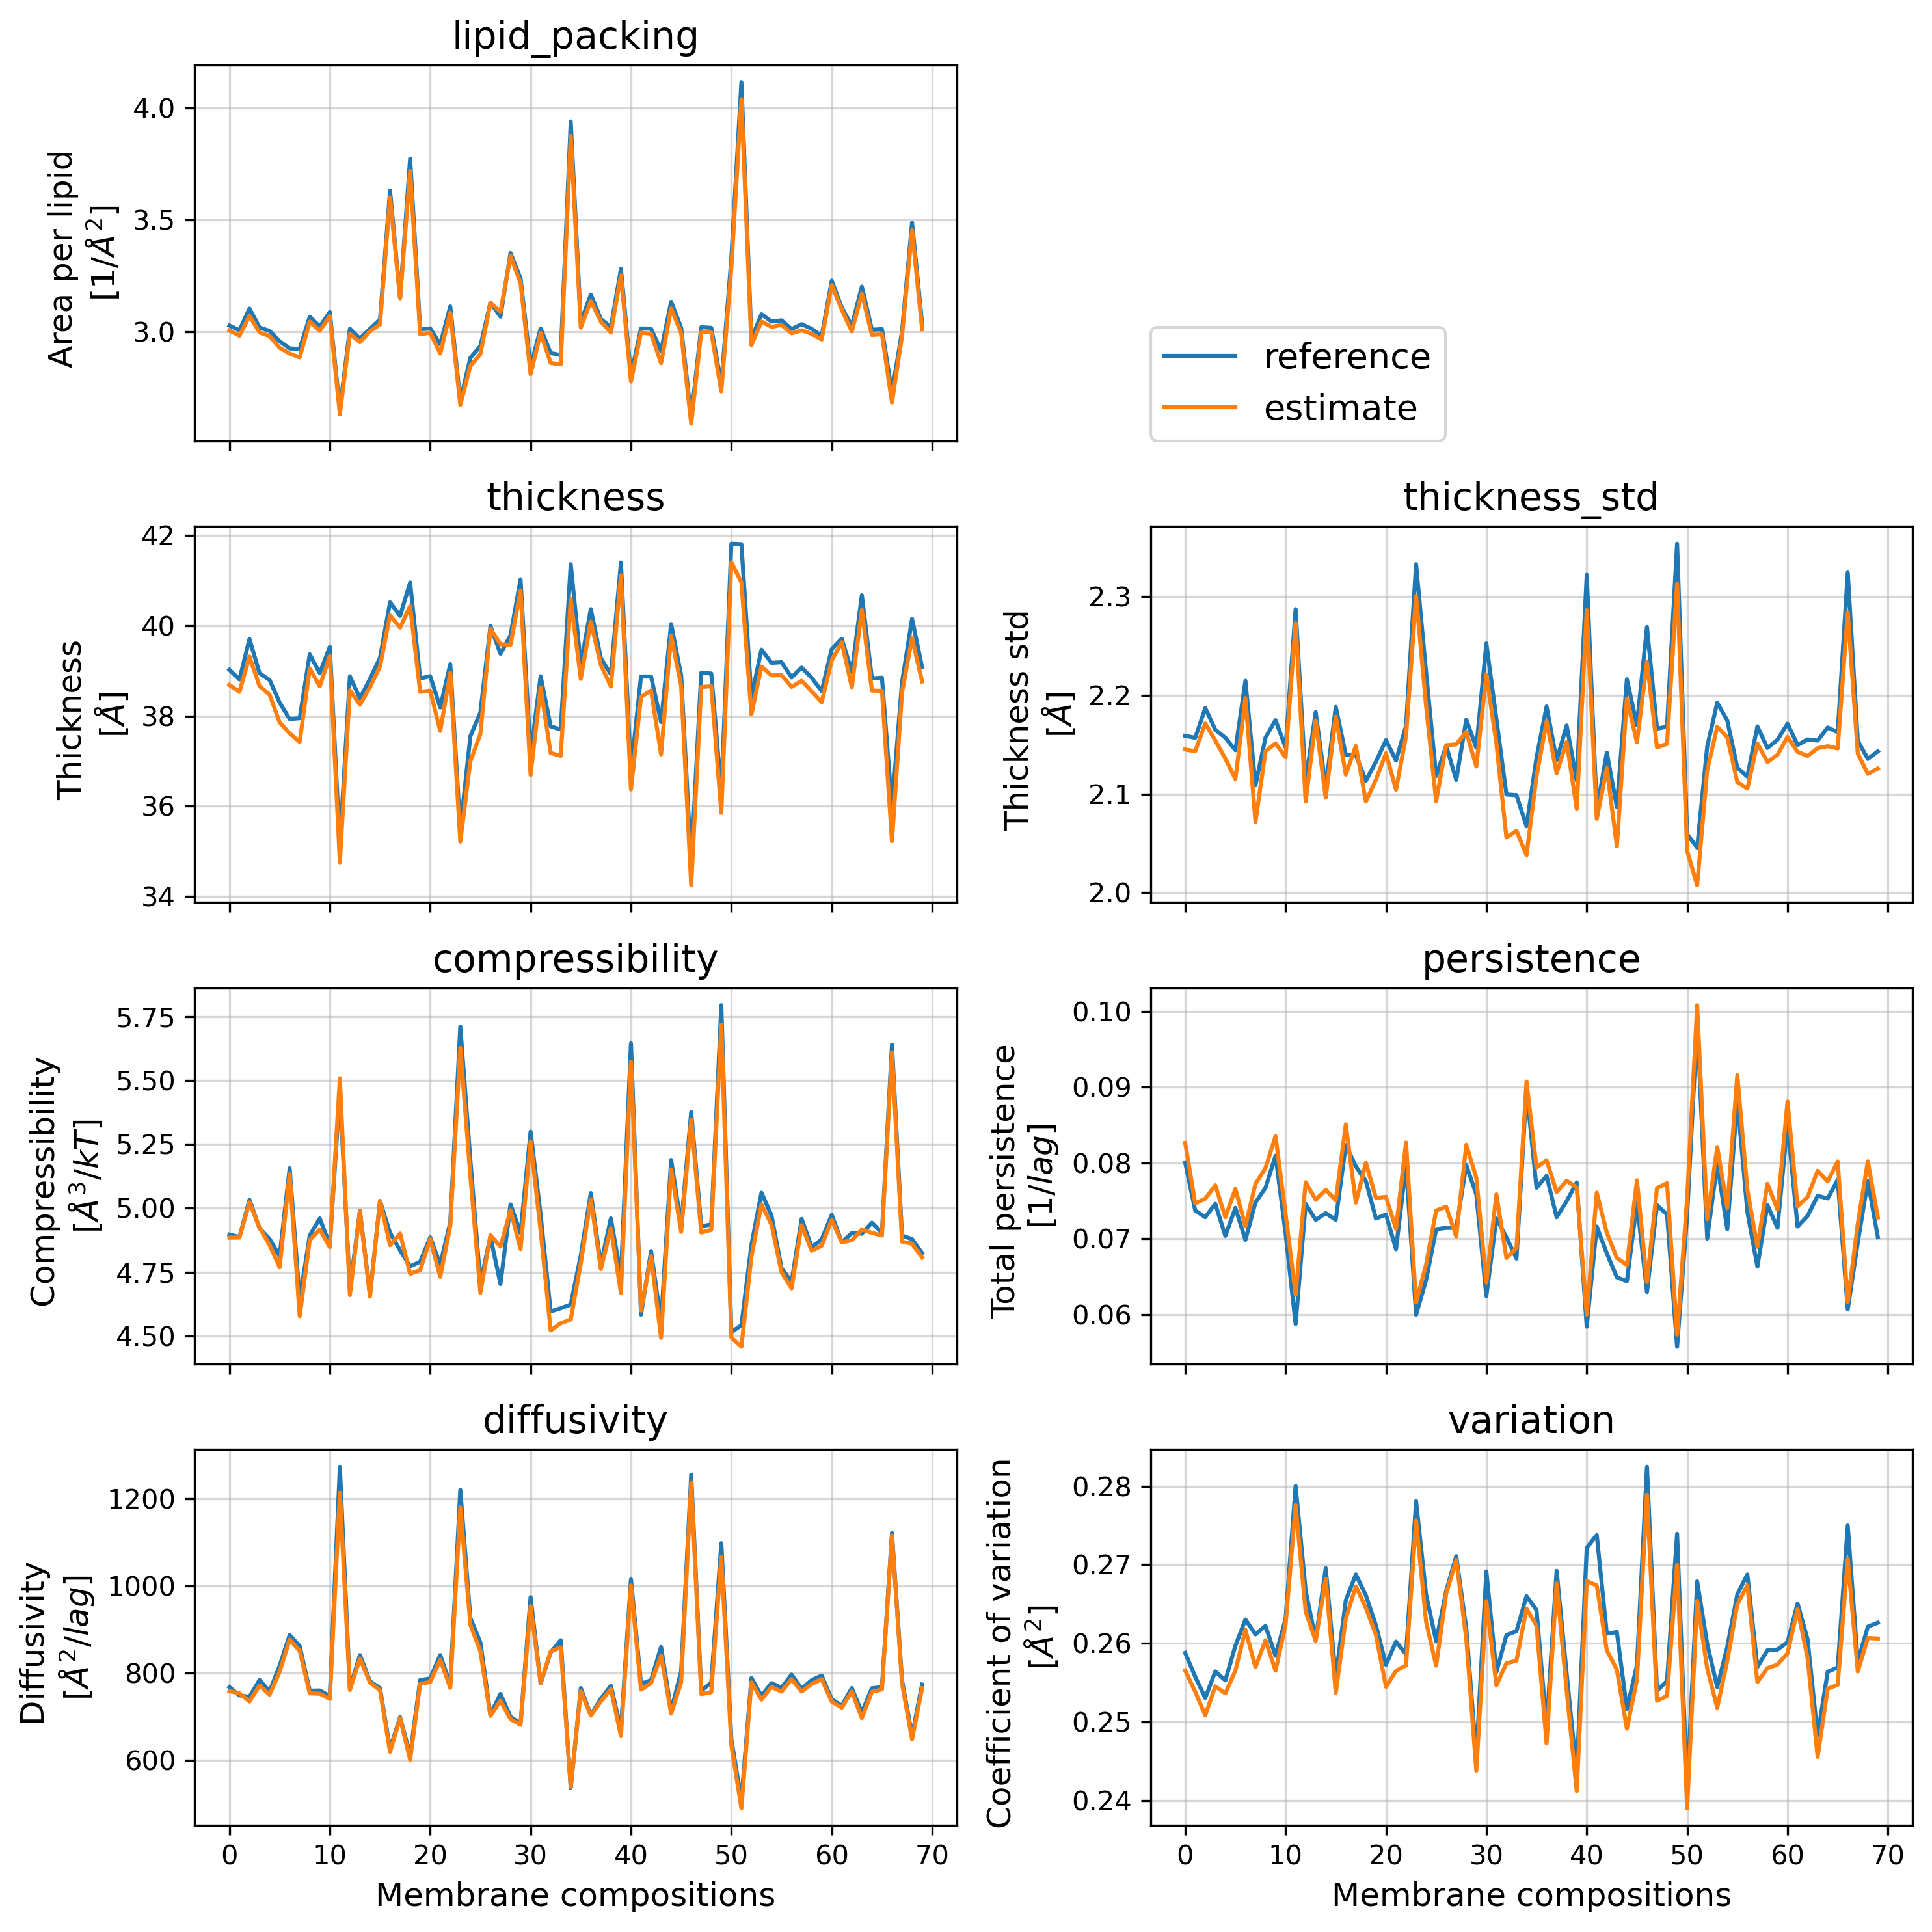

In [153]:
index = 0
units = ['Area per lipid \n[$1/\AA ^2$]', 
         'Thickness \n[$\AA$]', 
         'Thickness std \n[$\AA$]', 
         'Compressibility \n[$\AA^3 / kT]$',
         'Total persistence \n[$1/lag$]',
         'Diffusivity \n[$\AA^2/lag$]',
         'Coefficient of variation \n[$\AA^2$]']
fig, axes = plt.subplots(4, 2, figsize=(10, 10), dpi=300, sharex=True)
for i in range(8):
    
    ax = axes[int(i/2), i%2]  
    if i == 1:
        ax.plot(validation_dict['results'][:, index, :2], label=['reference', 'estimate'])
        ax.set_ylim(0,0.1)
        ax.legend(loc=(0, 0), fontsize=13)
        ax.axis('off')
        continue

    ax.plot(validation_dict['results'][:, index, :2], label=['reference', 'estimate'])
    ax.set_title(properties[index], fontsize=14)
    ax.grid(alpha=0.5)
    ax.set_ylabel(units[index], fontsize=12)
    if int(i/2) == 3:
        ax.set_xlabel('Membrane compositions', fontsize=12)
    index += 1
plt.tight_layout()
plt.show()